# 01 Data Processing and EDA

This notebook builds the final event-level dataset used for modelling. It combines structured macroeconomic release features, official release text, VIX context, and ES futures event-window market features.

Final event universe:

- CPI
- NFP
- PCE
- GDP_ADVANCE
- RETAIL_SALES

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path(os.environ.get("MACRO_PROJECT_ROOT", ".")).expanduser().resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"

STRUCTURED_PATH = DATA_RAW / "calendar_tables" / "structured_release_features.csv"
OFFICIAL_TEXT_PATH = DATA_RAW / "calendar_tables" / "official_text_clean.csv"
VIX_PATH = DATA_RAW / "vix" / "VIXCLS.csv"
DATABENTO_FOLDER = DATA_RAW / "databento"

MASTER_EVENTS_PATH = DATA_PROCESSED / "master_events.csv"
QUALITY_REPORT_PATH = DATA_PROCESSED / "master_events_quality_report.csv"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Structured features:", STRUCTURED_PATH)
print("Official text:", OFFICIAL_TEXT_PATH)
print("VIX:", VIX_PATH)
print("Databento folder:", DATABENTO_FOLDER)
print("Processed output folder:", DATA_PROCESSED)
print("Figures folder:", FIGURES)

Project root: <PROJECT_ROOT>
Structured features: <PROJECT_ROOT>/data/raw/calendar_tables/structured_release_features.csv
Official text: <PROJECT_ROOT>/data/raw/calendar_tables/official_text_clean.csv
VIX: <PROJECT_ROOT>/data/raw/vix/VIXCLS.csv
Databento folder: <PROJECT_ROOT>/data/raw/databento
Processed output folder: <PROJECT_ROOT>/data/processed
Figures folder: <PROJECT_ROOT>/outputs/figures


## 2. Load and inspect structured macro features

The structured file contains the manually compiled actual, forecast, previous, and surprise variables. Many columns are naturally blank because each event type only uses its own indicators.

In [3]:
structured = pd.read_csv(STRUCTURED_PATH)
structured["release_datetime_et"] = pd.to_datetime(structured["release_datetime_et"], errors="coerce")
structured["release_date"] = pd.to_datetime(structured["release_date"], errors="coerce")

expected_event_types = ["CPI", "NFP", "PCE", "GDP_ADVANCE", "RETAIL_SALES"]
actual_event_types = sorted(structured["event_type"].dropna().unique())

print("Structured shape:", structured.shape)
print("\nColumns:")
print(structured.columns.tolist())

print("\nEvent type counts:")
print(structured["event_type"].value_counts().sort_index())

print("\nExpected event types:")
print(expected_event_types)

print("\nActual event types:")
print(actual_event_types)

unexpected_event_types = []
for event_type in actual_event_types:
    if event_type not in expected_event_types:
        unexpected_event_types.append(event_type)

if len(unexpected_event_types) > 0:
    print("\nWarning: unexpected event types found:")
    print(unexpected_event_types)
else:
    print("\nEvent universe looks correct: no unexpected event types found.")

print("\nRelease date range:")
print(structured["release_date"].min(), "to", structured["release_date"].max())

display(structured.head())

Structured shape: (513, 37)

Columns:
['event_id', 'event_type', 'release_date', 'release_datetime_et', 'reference_period', 'average_hourly_earnings_mom_actual', 'average_hourly_earnings_mom_forecast', 'average_hourly_earnings_mom_previous', 'average_hourly_earnings_mom_surprise', 'core_cpi_mom_actual', 'core_cpi_mom_forecast', 'core_cpi_mom_previous', 'core_cpi_mom_surprise', 'core_pce_price_index_mom_actual', 'core_pce_price_index_mom_forecast', 'core_pce_price_index_mom_previous', 'core_pce_price_index_mom_surprise', 'gdp_growth_rate_qoq_advance_actual', 'gdp_growth_rate_qoq_advance_forecast', 'gdp_growth_rate_qoq_advance_previous', 'gdp_growth_rate_qoq_advance_surprise', 'headline_cpi_mom_actual', 'headline_cpi_mom_forecast', 'headline_cpi_mom_previous', 'headline_cpi_mom_surprise', 'nonfarm_payrolls_actual', 'nonfarm_payrolls_forecast', 'nonfarm_payrolls_previous', 'nonfarm_payrolls_surprise', 'retail_sales_mom_actual', 'retail_sales_mom_forecast', 'retail_sales_mom_previous', 're

,event_id,event_type,release_date,release_datetime_et,reference_period,average_hourly_earnings_mom_actual,average_hourly_earnings_mom_forecast,average_hourly_earnings_mom_previous,average_hourly_earnings_mom_surprise,core_cpi_mom_actual,...,nonfarm_payrolls_previous,nonfarm_payrolls_surprise,retail_sales_mom_actual,retail_sales_mom_forecast,retail_sales_mom_previous,retail_sales_mom_surprise,unemployment_rate_actual,unemployment_rate_forecast,unemployment_rate_previous,unemployment_rate_surprise
0,NFP_2016_01,NFP,2016-01-08,2016-01-08 08:30:00,Dec,0.0,0.2,0.2,-0.2,NaN,...,252000.0,92000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RETAIL_SALES_2016_01,RETAIL_SALES,2016-01-15,2016-01-15 08:30:00,Dec,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.1,0.1,0.4,-0.2,NaN,NaN,NaN,NaN
2,CPI_2016_01,CPI,2016-01-20,2016-01-20 08:30:00,Dec,NaN,NaN,NaN,NaN,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,2016-01-29,2016-01-29 08:30:00,2015 Q4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PCE_2016_02_2016-02-01,PCE,2016-02-01,2016-02-01 08:30:00,Dec,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Total missing values in structured dataframe:", int(structured.isna().sum().sum()))

missing_by_column = structured.isna().sum()
missing_by_column = missing_by_column[missing_by_column > 0]

print("\nColumns with missing values:")
print(missing_by_column)

surprise_columns = []
for column in structured.columns:
    if "surprise" in column:
        surprise_columns.append(column)

print("\nSurprise columns:")
print(surprise_columns)

print("\nMissing values in surprise columns:")
print(structured[surprise_columns].isna().sum())

Total missing values in structured dataframe: 12946

Columns with missing values:
average_hourly_earnings_mom_actual      394
average_hourly_earnings_mom_forecast    394
average_hourly_earnings_mom_previous    395
average_hourly_earnings_mom_surprise    394
core_cpi_mom_actual                     395
core_cpi_mom_forecast                   395
core_cpi_mom_previous                   395
core_cpi_mom_surprise                   395
core_pce_price_index_mom_actual         396
core_pce_price_index_mom_forecast       396
core_pce_price_index_mom_previous       397
core_pce_price_index_mom_surprise       396
gdp_growth_rate_qoq_advance_actual      473
gdp_growth_rate_qoq_advance_forecast    473
gdp_growth_rate_qoq_advance_previous    473
gdp_growth_rate_qoq_advance_surprise    473
headline_cpi_mom_actual                 395
headline_cpi_mom_forecast               395
headline_cpi_mom_previous               395
headline_cpi_mom_surprise               395
nonfarm_payrolls_actual               

## 3. Load and inspect official text

The official text file contains cleaned official release text from BLS, BEA, and Census. This text is preserved as `official_text`; a separate `modelling_text` field is created later for NLP features.

In [5]:
official_text = pd.read_csv(OFFICIAL_TEXT_PATH)

if "release_datetime_et" in official_text.columns:
    official_text["release_datetime_et"] = pd.to_datetime(official_text["release_datetime_et"], errors="coerce")

official_text["official_text"] = official_text["official_text"].fillna("").astype(str)
official_text["official_text_length"] = official_text["official_text"].str.len()

print("Official text shape:", official_text.shape)
print("\nColumns:")
print(official_text.columns.tolist())

print("\nEvent type counts:")
print(official_text["event_type"].value_counts().sort_index())

blank_text_count = int((official_text["official_text"].str.strip() == "").sum())
print("\nBlank official_text count:", blank_text_count)

print("\nAverage official_text_length by event_type:")
print(official_text.groupby("event_type")["official_text_length"].mean().round(1))

missing_text_columns = official_text.isna().sum()
missing_text_columns = missing_text_columns[missing_text_columns > 0]

print("\nMissing values by column:")
print(missing_text_columns)

display(official_text[["event_id", "event_type", "source_agency", "official_text_length"]].head())

Official text shape: (513, 8)

Columns:
['event_id', 'event_type', 'release_datetime_et', 'source_agency', 'official_url', 'official_text', 'text_length', 'official_text_length']

Event type counts:
event_type
CPI             118
GDP_ADVANCE      40
NFP             119
PCE             117
RETAIL_SALES    119
Name: count, dtype: int64

Blank official_text count: 0

Average official_text_length by event_type:
event_type
CPI             10257.0
GDP_ADVANCE      4016.6
NFP             17201.2
PCE              7408.9
RETAIL_SALES    20543.3
Name: official_text_length, dtype: float64

Missing values by column:
Series([], dtype: int64)


,event_id,event_type,source_agency,official_text_length
0,NFP_2016_01,NFP,BLS,18705
1,RETAIL_SALES_2016_01,RETAIL_SALES,CENSUS,18047
2,CPI_2016_01,CPI,BLS,23802
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,BEA,10661
4,PCE_2016_02_2016-02-01,PCE,BEA,8153


## 4. Check merge compatibility

`event_id` is a unique identifier created during the data compilation stage so that the numerical release features and the corresponding official text can be joined at event level.

In [6]:
structured_ids = set(structured["event_id"])
text_ids = set(official_text["event_id"])

structured_only_ids = sorted(structured_ids - text_ids)
text_only_ids = sorted(text_ids - structured_ids)
matching_ids = sorted(structured_ids.intersection(text_ids))

print("Unique structured event_ids:", len(structured_ids))
print("Unique text event_ids:", len(text_ids))
print("Matching event_ids:", len(matching_ids))
print("Structured-only event_ids:", len(structured_only_ids))
print("Text-only event_ids:", len(text_only_ids))

if len(structured_only_ids) > 0:
    print("\nExamples only in structured:")
    print(structured_only_ids[:10])

if len(text_only_ids) > 0:
    print("\nExamples only in official text:")
    print(text_only_ids[:10])

Unique structured event_ids: 513
Unique text event_ids: 513
Matching event_ids: 513
Structured-only event_ids: 0
Text-only event_ids: 0


## 5. Merge structured features and official text

In [7]:
official_columns = ["event_id", "official_text", "official_text_length", "source_agency", "official_url"]
available_official_columns = []

for column in official_columns:
    if column in official_text.columns:
        available_official_columns.append(column)

events = structured.merge(
    official_text[available_official_columns],
    on="event_id",
    how="left"
)

events["official_text"] = events["official_text"].fillna("").astype(str)

if "official_text_length" not in events.columns:
    events["official_text_length"] = events["official_text"].str.len()

print("Merged shape:", events.shape)
print("\nEvent type counts:")
print(events["event_type"].value_counts().sort_index())

missing_official_text = int((events["official_text"].str.strip() == "").sum())
missing_release_datetime = int(events["release_datetime_et"].isna().sum())

print("\nMissing official_text after merge:", missing_official_text)
print("Missing release_datetime_et after merge:", missing_release_datetime)

display(events[["event_id", "event_type", "release_datetime_et", "official_text_length"]].head())

Merged shape: (513, 41)

Event type counts:
event_type
CPI             118
GDP_ADVANCE      40
NFP             119
PCE             117
RETAIL_SALES    119
Name: count, dtype: int64

Missing official_text after merge: 0
Missing release_datetime_et after merge: 0


,event_id,event_type,release_datetime_et,official_text_length
0,NFP_2016_01,NFP,2016-01-08 08:30:00,18705
1,RETAIL_SALES_2016_01,RETAIL_SALES,2016-01-15 08:30:00,18047
2,CPI_2016_01,CPI,2016-01-20 08:30:00,23802
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,2016-01-29 08:30:00,10661
4,PCE_2016_02_2016-02-01,PCE,2016-02-01 08:30:00,8153


## 6. Clean modelling text

`official_text` is preserved exactly as the cleaned official source text. `modelling_text` is a separate field used later for FinBERT. Because ISM/PRNewswire has been removed from the final dataset, this step is now mostly a simple whitespace cleanup.

In [8]:
modelling_texts = []

for index, row in events.iterrows():
    text_value = str(row["official_text"])
    text_value = " ".join(text_value.split())
    modelling_texts.append(text_value.strip())

events["modelling_text"] = modelling_texts
events["modelling_text_length"] = events["modelling_text"].str.len()

print("Average official_text_length by event_type:")
print(events.groupby("event_type")["official_text_length"].mean().round(1))

print("\nAverage modelling_text_length by event_type:")
print(events.groupby("event_type")["modelling_text_length"].mean().round(1))

blank_modelling_text = int((events["modelling_text"].str.strip() == "").sum())
print("\nBlank modelling_text count:", blank_modelling_text)

display(events[["event_id", "event_type", "official_text_length", "modelling_text_length"]].head())

Average official_text_length by event_type:
event_type
CPI             10257.0
GDP_ADVANCE      4016.6
NFP             17201.2
PCE              7408.9
RETAIL_SALES    20543.3
Name: official_text_length, dtype: float64

Average modelling_text_length by event_type:
event_type
CPI             10221.2
GDP_ADVANCE      3993.1
NFP             17148.5
PCE              7333.1
RETAIL_SALES    20466.0
Name: modelling_text_length, dtype: float64

Blank modelling_text count: 0


,event_id,event_type,official_text_length,modelling_text_length
0,NFP_2016_01,NFP,18705,18645
1,RETAIL_SALES_2016_01,RETAIL_SALES,18047,18015
2,CPI_2016_01,CPI,23802,23733
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,10661,10602
4,PCE_2016_02_2016-02-01,PCE,8153,8089


## 7. Load VIX and add previous close

VIX is used as a pre-event market uncertainty/context variable. To avoid leakage, the feature uses the previous available VIX close strictly before the event date, not same-day close.

In [9]:
vix = pd.read_csv(VIX_PATH)

vix["observation_date"] = pd.to_datetime(vix["observation_date"], errors="coerce")
vix["VIXCLS"] = pd.to_numeric(vix["VIXCLS"], errors="coerce")
vix = vix.sort_values("observation_date").reset_index(drop=True)

print("VIX shape:", vix.shape)
print("VIX columns:", vix.columns.tolist())
print("VIX date range:", vix["observation_date"].min(), "to", vix["observation_date"].max())
print("Missing VIXCLS values:", int(vix["VIXCLS"].isna().sum()))

vix_valid = vix.dropna(subset=["observation_date", "VIXCLS"]).copy()

vix_previous_values = []

for index, row in events.iterrows():
    event_date = pd.to_datetime(row["release_date"], errors="coerce")

    if pd.isna(event_date):
        vix_previous_values.append(np.nan)
        continue

    previous_vix_rows = vix_valid[vix_valid["observation_date"] < event_date]

    if len(previous_vix_rows) == 0:
        vix_previous_values.append(np.nan)
    else:
        vix_previous_values.append(previous_vix_rows.iloc[-1]["VIXCLS"])

events["vix_previous_close"] = vix_previous_values

print("\nMissing vix_previous_close:", int(events["vix_previous_close"].isna().sum()))
print("\nVIX previous close summary:")
print(events["vix_previous_close"].describe())

display(events[["event_id", "release_date", "vix_previous_close"]].head())

VIX shape: (4153, 2)
VIX columns: ['observation_date', 'VIXCLS']
VIX date range: 2010-06-07 00:00:00 to 2026-05-06 00:00:00
Missing VIXCLS values: 120

Missing vix_previous_close: 0

VIX previous close summary:
count    513.000000
mean      18.565361
std        7.270500
min        9.190000
25%       13.650000
50%       16.640000
75%       21.770000
max       82.690000
Name: vix_previous_close, dtype: float64


,event_id,release_date,vix_previous_close
0,NFP_2016_01,2016-01-08,24.99
1,RETAIL_SALES_2016_01,2016-01-15,23.95
2,CPI_2016_01,2016-01-20,26.05
3,GDP_ADVANCE_2016_Q4,2016-01-29,22.42
4,PCE_2016_02_2016-02-01,2016-02-01,20.20


## 8. Load Databento ES futures data

ES futures prices are used to construct pre-event return, pre-event realised volatility, post-event return, and labels. If multiple ES contracts exist for the same minute, this notebook keeps the outright ES contract with the highest minute volume.

In [10]:
csv_files = list(DATABENTO_FOLDER.glob("*.csv"))

databento_path = None

for file in csv_files:
    file_name = file.name.lower()

    if "glbx" in file_name or "es" in file_name or "ohlcv" in file_name:
        databento_path = file
        break

if databento_path is None and len(csv_files) > 0:
    databento_path = csv_files[0]

print("Databento file found:")
print(databento_path)

if databento_path is None:
    raise FileNotFoundError("No Databento CSV file found in data/raw/databento/")

Databento file found:
<PROJECT_ROOT>/data/raw/databento/glbx-mdp3-20100606-20260506.ohlcv-1m.csv


In [11]:
needed_columns = ["ts_event", "open", "high", "low", "close", "volume", "symbol"]

# The Databento file is large, so read it in chunks.
# We only keep rows close to the event sample period and only outright ES contracts.
event_times = pd.to_datetime(events["release_datetime_et"], errors="coerce")
start_et = event_times.min() - pd.Timedelta(days=1)
end_et = event_times.max() + pd.Timedelta(days=1)

start_utc = start_et.tz_localize("America/New_York").tz_convert("UTC")
end_utc = end_et.tz_localize("America/New_York").tz_convert("UTC")

start_text = start_utc.strftime("%Y-%m-%dT%H:%M:%S")
end_text = end_utc.strftime("%Y-%m-%dT%H:%M:%S")

print("Loading Databento rows between:")
print(start_text, "and", end_text)

chunk_size = 500_000
chunks = []
chunk_number = 0
rows_kept = 0

for chunk in pd.read_csv(databento_path, usecols=needed_columns, chunksize=chunk_size):
    chunk_number += 1

    chunk["symbol"] = chunk["symbol"].astype(str)
    symbol_text = chunk["symbol"]

    starts_with_es = symbol_text.str.startswith("ES")
    is_not_spread = symbol_text.str.contains("-", regex=False) == False
    chunk = chunk[starts_with_es & is_not_spread].copy()

    ts_text = chunk["ts_event"].astype(str)
    date_mask = (ts_text >= start_text) & (ts_text <= end_text)
    chunk = chunk[date_mask].copy()

    if len(chunk) > 0:
        chunks.append(chunk)
        rows_kept += len(chunk)

    if chunk_number % 5 == 0:
        print("Chunks read:", chunk_number, "rows kept so far:", rows_kept)

if len(chunks) == 0:
    raise ValueError("No Databento rows found for the event sample period.")

market = pd.concat(chunks, ignore_index=True)

# Explicit ISO8601 parsing is faster and avoids the very slow full-column conversion.
market["ts_event_utc"] = pd.to_datetime(
    market["ts_event"],
    utc=True,
    errors="coerce",
    format="ISO8601",
    cache=False,
)
market["ts_event_et"] = market["ts_event_utc"].dt.tz_convert("America/New_York")

for column in ["open", "high", "low", "close", "volume"]:
    market[column] = pd.to_numeric(market[column], errors="coerce")

market = market.dropna(subset=["ts_event_et", "close", "symbol"])
market = market[market["close"] > 0].copy()
market = market.sort_values("ts_event_et").reset_index(drop=True)

print("Market raw shape after date/symbol filtering and cleaning:", market.shape)
print("Market columns:", market.columns.tolist())
print("Market ET date range:", market["ts_event_et"].min(), "to", market["ts_event_et"].max())
print("Symbol sample:")
print(market["symbol"].drop_duplicates().head(10).to_string(index=False))

display(market.head())

Loading Databento rows between:
2016-01-07T13:30:00 and 2025-12-24T13:30:00
Chunks read: 5 rows kept so far: 0
Chunks read: 10 rows kept so far: 2052008
Chunks read: 15 rows kept so far: 4239183
Market raw shape after date/symbol filtering and cleaning: (4892261, 9)
Market columns: ['ts_event', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'ts_event_utc', 'ts_event_et']
Market ET date range: 2016-01-07 08:30:00-05:00 to 2025-12-24 08:29:00-05:00
Symbol sample:
ESH6
ESM6
ESU6
ESZ6
ESH7
ESM7
ESU7
ESZ7
ESH8
ESM8


,ts_event,open,high,low,close,volume,symbol,ts_event_utc,ts_event_et
0,2016-01-07T13:30:00.000000000Z,1940.50,1941.00,1940.25,1940.50,612,ESH6,2016-01-07 13:30:00+00:00,2016-01-07 08:30:00-05:00
1,2016-01-07T13:31:00.000000000Z,1940.50,1941.75,1940.25,1941.75,1080,ESH6,2016-01-07 13:31:00+00:00,2016-01-07 08:31:00-05:00
2,2016-01-07T13:31:00.000000000Z,1933.75,1933.75,1933.75,1933.75,2,ESM6,2016-01-07 13:31:00+00:00,2016-01-07 08:31:00-05:00
3,2016-01-07T13:32:00.000000000Z,1934.00,1934.00,1934.00,1934.00,1,ESM6,2016-01-07 13:32:00+00:00,2016-01-07 08:32:00-05:00
4,2016-01-07T13:32:00.000000000Z,1941.75,1941.75,1941.00,1941.25,845,ESH6,2016-01-07 13:32:00+00:00,2016-01-07 08:32:00-05:00


In [12]:
symbol_text = market["symbol"].astype(str)
starts_with_es = symbol_text.str.startswith("ES")
is_not_spread = symbol_text.str.contains("-", regex=False) == False

outright_es = market[starts_with_es & is_not_spread].copy()
outright_es = outright_es.sort_values(["ts_event_et", "volume"])

market_minute = outright_es.drop_duplicates(subset=["ts_event_et"], keep="last").copy()
market_minute = market_minute.sort_values("ts_event_et").reset_index(drop=True)

print("Outright ES rows:", len(outright_es))
print("Market minute rows:", len(market_minute))
print("Market minute date range:", market_minute["ts_event_et"].min(), "to", market_minute["ts_event_et"].max())
print("Market minute symbol sample:")
print(market_minute["symbol"].drop_duplicates().head(10).to_string(index=False))

display(market_minute.head())

Outright ES rows: 4892261
Market minute rows: 3500522
Market minute date range: 2016-01-07 08:30:00-05:00 to 2025-12-24 08:29:00-05:00
Market minute symbol sample:
ESH6
ESM6
ESU6
ESZ6
ESH7
ESM7
ESU7
ESZ7
ESH8
ESU8


,ts_event,open,high,low,close,volume,symbol,ts_event_utc,ts_event_et
0,2016-01-07T13:30:00.000000000Z,1940.50,1941.00,1940.25,1940.50,612,ESH6,2016-01-07 13:30:00+00:00,2016-01-07 08:30:00-05:00
1,2016-01-07T13:31:00.000000000Z,1940.50,1941.75,1940.25,1941.75,1080,ESH6,2016-01-07 13:31:00+00:00,2016-01-07 08:31:00-05:00
2,2016-01-07T13:32:00.000000000Z,1941.75,1941.75,1941.00,1941.25,845,ESH6,2016-01-07 13:32:00+00:00,2016-01-07 08:32:00-05:00
3,2016-01-07T13:33:00.000000000Z,1941.25,1941.50,1940.50,1940.75,1224,ESH6,2016-01-07 13:33:00+00:00,2016-01-07 08:33:00-05:00
4,2016-01-07T13:34:00.000000000Z,1940.75,1941.50,1940.25,1940.25,1927,ESH6,2016-01-07 13:34:00+00:00,2016-01-07 08:34:00-05:00


## 9. Build market features

For each macro release, this notebook uses a 30-minute pre-event window and a 30-minute post-event window. Timestamps are handled in America/New_York. The main target return is the 30-minute post-event ES log return, but percentage return versions are also created for easier interpretation in EDA plots.

In [13]:
market_times = market_minute["ts_event_et"].reset_index(drop=True)
market_closes = market_minute["close"].reset_index(drop=True)

# Find the first available ES close at or after the target time.
def close_at_or_after(target_time):
    position = market_times.searchsorted(target_time)

    if position >= len(market_times):
        return np.nan, pd.NaT

    return float(market_closes.iloc[position]), market_times.iloc[position]

In [14]:
market_features = []

for index, row in events.iterrows():
    event_id = row["event_id"]
    event_time = pd.to_datetime(row["release_datetime_et"], errors="coerce")

    result = {
        "event_id": event_id,
        "price_pre_start": np.nan,
        "price_at_event": np.nan,
        "price_post_end": np.nan,
        "matched_pre_start_time": pd.NaT,
        "matched_event_time": pd.NaT,
        "matched_post_end_time": pd.NaT,
        "pre_event_return": np.nan,
        "pre_event_return_simple": np.nan,
        "pre_event_return_pct": np.nan,
        "post_event_30min_return": np.nan,
        "post_event_30min_return_simple": np.nan,
        "post_event_30min_return_pct": np.nan,
        "pre_event_realised_volatility": np.nan,
        "market_window_rows": 0,
        "market_feature_success": False,
        "market_feature_error": "",
    }

    if pd.isna(event_time):
        result["market_feature_error"] = "missing release_datetime_et"
        market_features.append(result)
        continue

    if event_time.tzinfo is None:
        event_time = event_time.tz_localize("America/New_York")
    else:
        event_time = event_time.tz_convert("America/New_York")

    pre_start = event_time - pd.Timedelta(minutes=30)
    post_end = event_time + pd.Timedelta(minutes=30)

    price_pre_start, matched_pre_start_time = close_at_or_after(pre_start)
    price_at_event, matched_event_time = close_at_or_after(event_time)
    price_post_end, matched_post_end_time = close_at_or_after(post_end)

    result["price_pre_start"] = price_pre_start
    result["price_at_event"] = price_at_event
    result["price_post_end"] = price_post_end
    result["matched_pre_start_time"] = matched_pre_start_time
    result["matched_event_time"] = matched_event_time
    result["matched_post_end_time"] = matched_post_end_time

    prices_available = True
    for price in [price_pre_start, price_at_event, price_post_end]:
        if pd.isna(price) or price <= 0:
            prices_available = False

    if prices_available == False:
        result["market_feature_error"] = "missing event window price"
        market_features.append(result)
        continue

    result["pre_event_return"] = np.log(price_at_event / price_pre_start)
    result["post_event_30min_return"] = np.log(price_post_end / price_at_event)

    result["pre_event_return_simple"] = (price_at_event / price_pre_start) - 1
    result["post_event_30min_return_simple"] = (price_post_end / price_at_event) - 1

    result["pre_event_return_pct"] = result["pre_event_return_simple"] * 100
    result["post_event_30min_return_pct"] = result["post_event_30min_return_simple"] * 100

    pre_window_mask = (market_minute["ts_event_et"] >= pre_start) & (market_minute["ts_event_et"] <= event_time)
    pre_window = market_minute[pre_window_mask].copy()
    result["market_window_rows"] = len(pre_window)

    if len(pre_window) >= 2:
        returns = np.log(pre_window["close"] / pre_window["close"].shift(1)).dropna()

        # Realised volatility over the 30-minute pre-event window:
        # square root of summed squared 1-minute log returns.
        result["pre_event_realised_volatility"] = np.sqrt((returns ** 2).sum())
    else:
        result["pre_event_realised_volatility"] = np.nan

    result["market_feature_success"] = True
    result["market_feature_error"] = ""
    market_features.append(result)

market_features_df = pd.DataFrame(market_features)

events = events.merge(market_features_df, on="event_id", how="left")

print("Market feature success counts:")
print(events["market_feature_success"].value_counts(dropna=False))

print("\nMost common market feature errors:")
failed_market_rows = events[events["market_feature_success"] == False]
print(failed_market_rows["market_feature_error"].value_counts().head())

print("\nMissing post_event_30min_return:", int(events["post_event_30min_return"].isna().sum()))

print("\nPost-event 30-minute log return summary:")
print(events["post_event_30min_return"].describe())

print("\nPost-event 30-minute percentage return summary:")
print(events["post_event_30min_return_pct"].describe())

print("\nPre-event realised volatility summary:")
print(events["pre_event_realised_volatility"].describe())

display(events[["event_id", "event_type", "release_datetime_et", "post_event_30min_return_pct", "market_feature_success"]].head())

Market feature success counts:
market_feature_success
True    513
Name: count, dtype: int64

Most common market feature errors:
Series([], Name: count, dtype: int64)

Missing post_event_30min_return: 0

Post-event 30-minute log return summary:
count    513.000000
mean       0.000101
std        0.002498
min       -0.010622
25%       -0.000868
50%        0.000094
75%        0.001103
max        0.011466
Name: post_event_30min_return, dtype: float64

Post-event 30-minute percentage return summary:
count    513.000000
mean       0.010427
std        0.249873
min       -1.056578
25%       -0.086751
50%        0.009359
75%        0.110396
max        1.153192
Name: post_event_30min_return_pct, dtype: float64

Pre-event realised volatility summary:
count    509.000000
mean       0.002458
std        0.003050
min        0.000380
25%        0.000848
50%        0.001441
75%        0.002812
max        0.025978
Name: pre_event_realised_volatility, dtype: float64


,event_id,event_type,release_datetime_et,post_event_30min_return_pct,market_feature_success
0,NFP_2016_01,NFP,2016-01-08 08:30:00,-0.191595,True
1,RETAIL_SALES_2016_01,RETAIL_SALES,2016-01-15 08:30:00,-0.386564,True
2,CPI_2016_01,CPI,2016-01-20 08:30:00,0.108548,True
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,2016-01-29 08:30:00,0.092409,True
4,PCE_2016_02_2016-02-01,PCE,2016-02-01 08:30:00,0.143547,True


## 10. Construct labels

The main task is binary classification of 30-minute post-event ES direction. The simple 3-class label is only a temporary robustness-check label. The final neutral threshold can be refined later using the training-period distribution only.

In [15]:
binary_labels = []

for value in events["post_event_30min_return"]:
    if pd.isna(value):
        binary_labels.append(np.nan)
    elif value > 0:
        binary_labels.append(1)
    else:
        binary_labels.append(0)

events["label_binary"] = binary_labels

neutral_threshold = 0.0005
three_class_labels = []

for value in events["post_event_30min_return_simple"]:
    if pd.isna(value):
        three_class_labels.append(np.nan)
    elif value > neutral_threshold:
        three_class_labels.append("UP")
    elif value < -neutral_threshold:
        three_class_labels.append("DOWN")
    else:
        three_class_labels.append("NEUTRAL")

events["label_3class_simple"] = three_class_labels

print("label_binary counts including missing:")
print(events["label_binary"].value_counts(dropna=False))

print("\nlabel_3class_simple counts including missing:")
print(events["label_3class_simple"].value_counts(dropna=False))

label_binary counts including missing:
label_binary
1    268
0    245
Name: count, dtype: int64

label_3class_simple counts including missing:
label_3class_simple
UP         206
DOWN       166
NEUTRAL    141
Name: count, dtype: int64


## 11. EDA after full dataset is built

In [16]:
print("Final event_type counts:")
print(events["event_type"].value_counts().sort_index())

important_columns = [
    "modelling_text",
    "vix_previous_close",
    "pre_event_return",
    "pre_event_realised_volatility",
    "post_event_30min_return",
    "label_binary",
]

missing_summary = []

for column in important_columns:
    missing_count = int(events[column].isna().sum())
    missing_summary.append({"column": column, "missing_count": missing_count})

missing_summary_df = pd.DataFrame(missing_summary)
print("\nMissing values in important columns:")
display(missing_summary_df)

print("\nBinary label balance overall:")
print(events["label_binary"].value_counts(dropna=False))

print("\nBinary label balance by event_type:")
label_by_event_type = events.pivot_table(
    index="event_type",
    columns="label_binary",
    values="event_id",
    aggfunc="count",
    fill_value=0,
)
display(label_by_event_type)

print("\nAverage post-event return (%) by event_type:")
print(events.groupby("event_type")["post_event_30min_return_pct"].mean().sort_index())

print("\nAverage modelling_text_length by event_type:")
print(events.groupby("event_type")["modelling_text_length"].mean().sort_index())

Final event_type counts:
event_type
CPI             118
GDP_ADVANCE      40
NFP             119
PCE             117
RETAIL_SALES    119
Name: count, dtype: int64

Missing values in important columns:


,column,missing_count
0,modelling_text,0
1,vix_previous_close,0
2,pre_event_return,0
3,pre_event_realised_volatility,4
4,post_event_30min_return,0
5,label_binary,0



Binary label balance overall:
label_binary
1    268
0    245
Name: count, dtype: int64

Binary label balance by event_type:


label_binary,0,1
event_type,,
CPI,53,65
GDP_ADVANCE,15,25
NFP,50,69
PCE,65,52
RETAIL_SALES,62,57



Average post-event return (%) by event_type:
event_type
CPI            -0.002232
GDP_ADVANCE     0.055831
NFP             0.040204
PCE            -0.006513
RETAIL_SALES   -0.005403
Name: post_event_30min_return_pct, dtype: float64

Average modelling_text_length by event_type:
event_type
CPI             10221.245763
GDP_ADVANCE      3993.100000
NFP             17148.487395
PCE              7333.094017
RETAIL_SALES    20466.025210
Name: modelling_text_length, dtype: float64


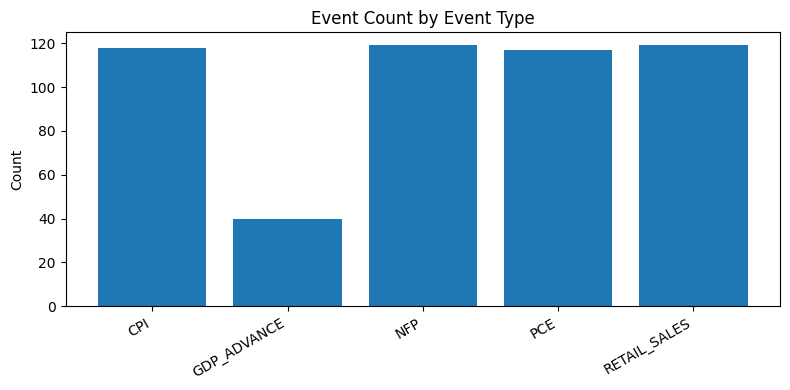

In [17]:
event_counts = events["event_type"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(event_counts.index, event_counts.values)
plt.title("Event Count by Event Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "event_count_by_event_type.png", dpi=150)
plt.show()

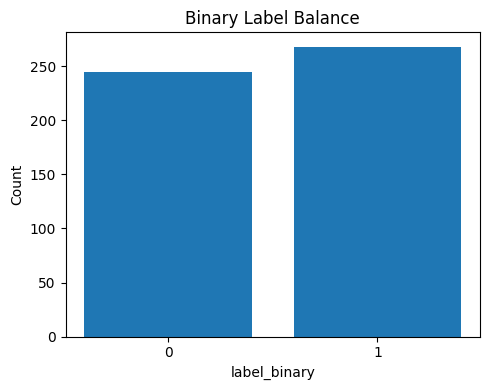

In [18]:
label_counts = events["label_binary"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Binary Label Balance")
plt.xlabel("label_binary")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES / "label_balance_overall.png", dpi=150)
plt.show()

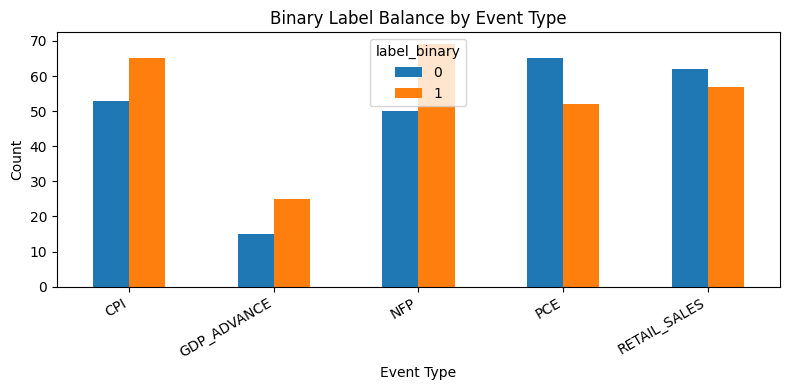

In [19]:
label_by_event_type.plot(kind="bar", figsize=(8, 4))
plt.title("Binary Label Balance by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "label_balance_by_event_type.png", dpi=150)
plt.show()

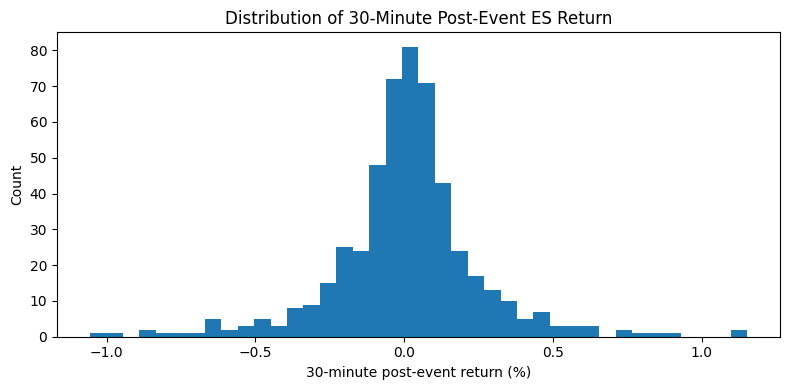

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(events["post_event_30min_return_pct"].dropna(), bins=40)
plt.title("Distribution of 30-Minute Post-Event ES Return")
plt.xlabel("30-minute post-event return (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES / "post_event_return_distribution.png", dpi=150)
plt.show()

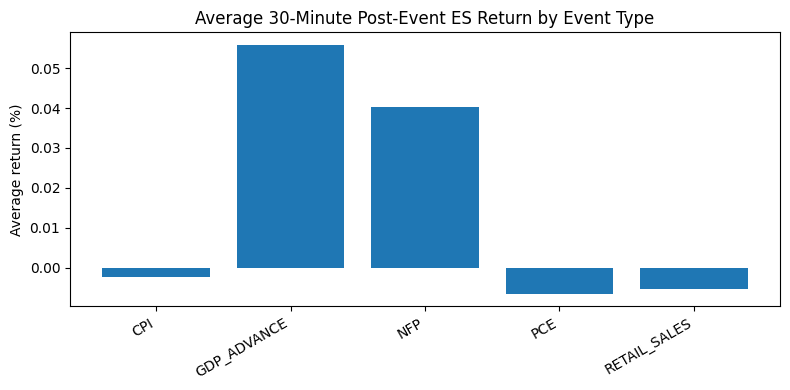

In [21]:
average_return_pct = events.groupby("event_type")["post_event_30min_return_pct"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(average_return_pct.index, average_return_pct.values)
plt.title("Average 30-Minute Post-Event ES Return by Event Type")
plt.ylabel("Average return (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "average_post_event_return_by_event_type.png", dpi=150)
plt.show()

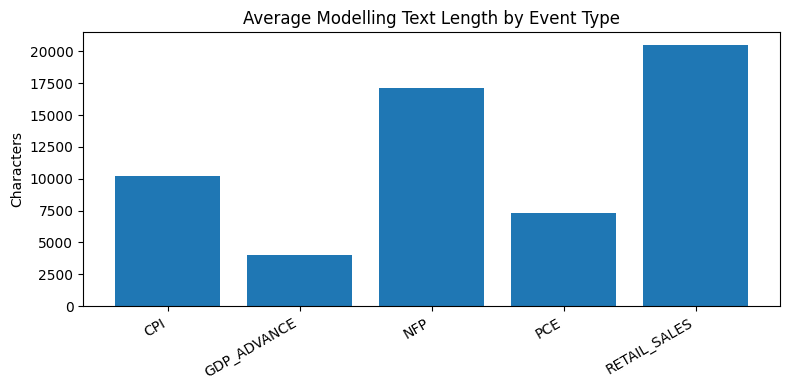

In [22]:
average_text_length = events.groupby("event_type")["modelling_text_length"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(average_text_length.index, average_text_length.values)
plt.title("Average Modelling Text Length by Event Type")
plt.ylabel("Characters")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "modelling_text_length_by_event_type.png", dpi=150)
plt.show()

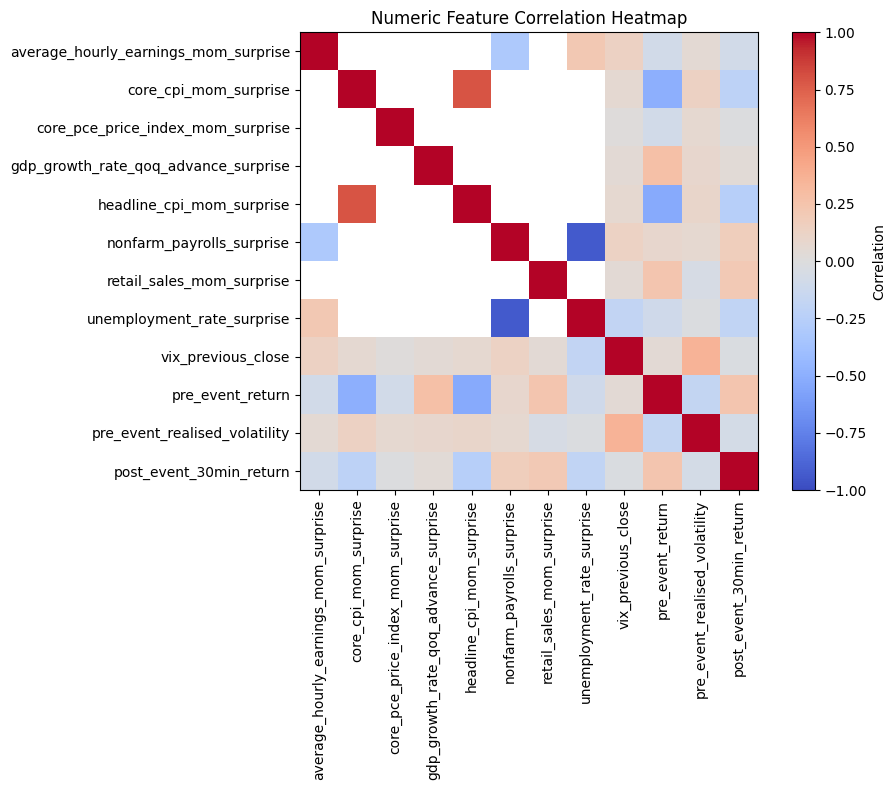

In [23]:
numeric_columns = []

for column in events.columns:
    if "surprise" in column:
        numeric_columns.append(column)

extra_numeric_columns = [
    "vix_previous_close",
    "pre_event_return",
    "pre_event_realised_volatility",
    "post_event_30min_return",
]

for column in extra_numeric_columns:
    if column in events.columns:
        numeric_columns.append(column)

numeric_data = events[numeric_columns].copy()
correlation_matrix = numeric_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES / "numeric_feature_correlation_heatmap.png", dpi=150)
plt.show()

## 12. Save outputs

In [24]:
events.to_csv(MASTER_EVENTS_PATH, index=False)

quality_rows = []

for event_type in sorted(events["event_type"].dropna().unique()):
    subset = events[events["event_type"] == event_type]

    missing_vix_count = int(subset["vix_previous_close"].isna().sum())
    missing_market_features_count = int((subset["market_feature_success"] == False).sum())
    missing_label_count = int(subset["label_binary"].isna().sum())

    quality_rows.append({
        "event_type": event_type,
        "row_count": len(subset),
        "missing_vix_count": missing_vix_count,
        "missing_market_features_count": missing_market_features_count,
        "missing_label_count": missing_label_count,
        "average_modelling_text_length": subset["modelling_text_length"].mean(),
        "average_post_event_30min_return_pct": subset["post_event_30min_return_pct"].mean(),
        "average_pre_event_realised_volatility": subset["pre_event_realised_volatility"].mean(),
    })

quality_report = pd.DataFrame(quality_rows)
quality_report.to_csv(QUALITY_REPORT_PATH, index=False)

print("Saved master_events.csv:")
print(MASTER_EVENTS_PATH)

print("\nSaved quality report:")
print(QUALITY_REPORT_PATH)

display(quality_report)

Saved master_events.csv:
<PROJECT_ROOT>/data/processed/master_events.csv

Saved quality report:
<PROJECT_ROOT>/data/processed/master_events_quality_report.csv


,event_type,row_count,missing_vix_count,missing_market_features_count,missing_label_count,average_modelling_text_length,average_post_event_30min_return_pct,average_pre_event_realised_volatility
0,CPI,118,0,0,0,10221.245763,-0.002232,0.003830
1,GDP_ADVANCE,40,0,0,0,3993.100000,0.055831,0.001490
2,NFP,119,0,0,0,17148.487395,0.040204,0.002718
3,PCE,117,0,0,0,7333.094017,-0.006513,0.001509
4,RETAIL_SALES,119,0,0,0,20466.025210,-0.005403,0.002107


## 13. Final summary

In [25]:
print("Final row count:", len(events))

print("\nEvent type counts:")
print(events["event_type"].value_counts().sort_index())

print("\nDate range:")
print(events["release_date"].min(), "to", events["release_date"].max())

print("\nMissing VIX count:", int(events["vix_previous_close"].isna().sum()))

print("\nMarket feature success/failure count:")
print(events["market_feature_success"].value_counts(dropna=False))

print("\nlabel_binary counts:")
print(events["label_binary"].value_counts(dropna=False))

print("\nlabel_3class_simple counts:")
print(events["label_3class_simple"].value_counts(dropna=False))

print("\nOutput files:")
print("Master events:", MASTER_EVENTS_PATH)
print("Quality report:", QUALITY_REPORT_PATH)
print("Figures folder:", FIGURES)

Final row count: 513

Event type counts:
event_type
CPI             118
GDP_ADVANCE      40
NFP             119
PCE             117
RETAIL_SALES    119
Name: count, dtype: int64

Date range:
2016-01-08 00:00:00 to 2025-12-23 00:00:00

Missing VIX count: 0

Market feature success/failure count:
market_feature_success
True    513
Name: count, dtype: int64

label_binary counts:
label_binary
1    268
0    245
Name: count, dtype: int64

label_3class_simple counts:
label_3class_simple
UP         206
DOWN       166
NEUTRAL    141
Name: count, dtype: int64

Output files:
Master events: <PROJECT_ROOT>/data/processed/master_events.csv
Quality report: <PROJECT_ROOT>/data/processed/master_events_quality_report.csv
Figures folder: <PROJECT_ROOT>/outputs/figures
